In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
df = pd.read_csv(r"C:\Users\User\Desktop\DSA210\data\processed\master_dataset.csv")

print("Shape: ", df.shape)
print("n\Columns: ", df.columns.tolist())
print("\nFirst 5 rows")
df.head()


Shape:  (26759, 29)
n\Columns:  ['raceId', 'year', 'round', 'date', 'name', 'circuitId', 'circuitRef', 'country', 'location', 'lat', 'long', 'driverId', 'driver_name', 'nationality', 'constructorId', 'constructor_name', 'constructor_nationality', 'grid', 'positionOrder', 'points', 'laps', 'milliseconds', 'is_winner', 'champ_points_pre', 'champ_pos_pre', 'champ_wins_pre', 'constructor_points_pre', 'constructor_pos_pre', 'started_from_pole']

First 5 rows


,raceId,year,round,date,name,circuitId,circuitRef,country,location,lat,...,points,laps,milliseconds,is_winner,champ_points_pre,champ_pos_pre,champ_wins_pre,constructor_points_pre,constructor_pos_pre,started_from_pole
0,18,2008,1,2008-03-16,Australian Grand Prix,1,albert_park,Australia,Melbourne,-37.8497,...,10.0,58,5690616.0,1,10.0,1.0,1.0,14.0,1.0,1
1,18,2008,1,2008-03-16,Australian Grand Prix,1,albert_park,Australia,Melbourne,-37.8497,...,8.0,58,5696094.0,0,8.0,2.0,0.0,8.0,3.0,0
2,18,2008,1,2008-03-16,Australian Grand Prix,1,albert_park,Australia,Melbourne,-37.8497,...,6.0,58,5698779.0,0,6.0,3.0,0.0,9.0,2.0,0
3,18,2008,1,2008-03-16,Australian Grand Prix,1,albert_park,Australia,Melbourne,-37.8497,...,5.0,58,5707797.0,0,5.0,4.0,0.0,5.0,4.0,0
4,18,2008,1,2008-03-16,Australian Grand Prix,1,albert_park,Australia,Melbourne,-37.8497,...,4.0,58,5708630.0,0,4.0,5.0,0.0,14.0,1.0,0


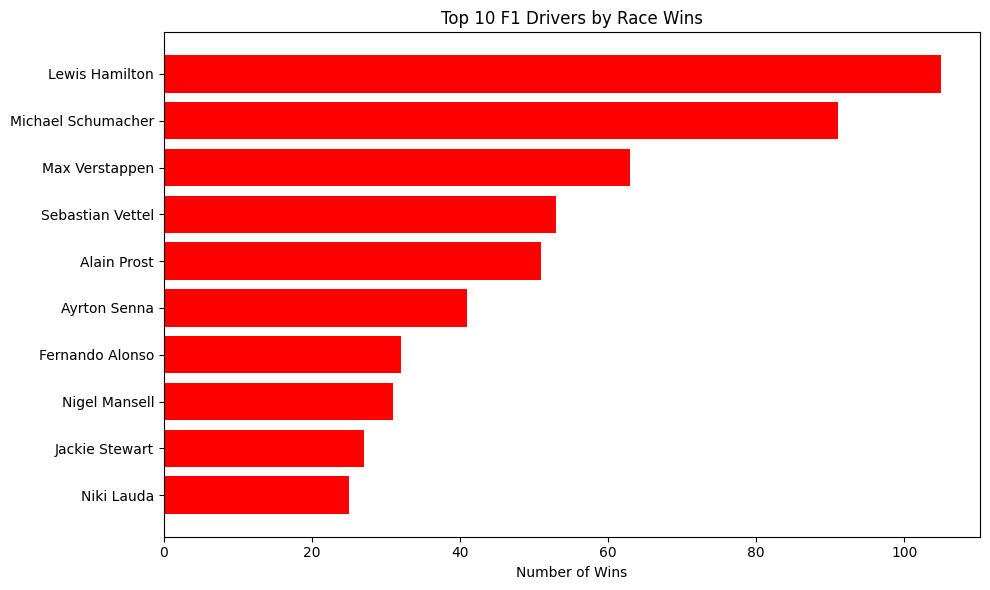

In [4]:
winners = df[df["is_winner"] == 1]
top_drivers = winners["driver_name"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_drivers.index, top_drivers.values, color="red")
plt.xlabel("Number of Wins")
plt.title("Top 10 F1 Drivers by Race Wins")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

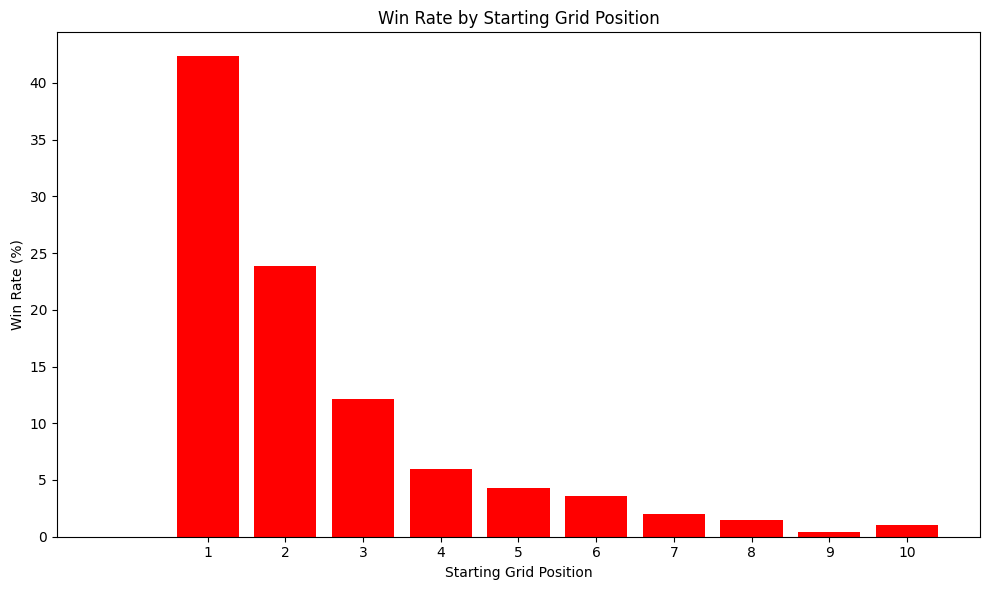

In [5]:
# Win rate by grid position (top 10 positions only)
grid_wins = df[df["grid"] <= 10].groupby("grid")["is_winner"].mean() * 100

plt.figure(figsize=(10, 6))
plt.bar(grid_wins.index, grid_wins.values, color="red")
plt.xlabel("Starting Grid Position")
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Starting Grid Position")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

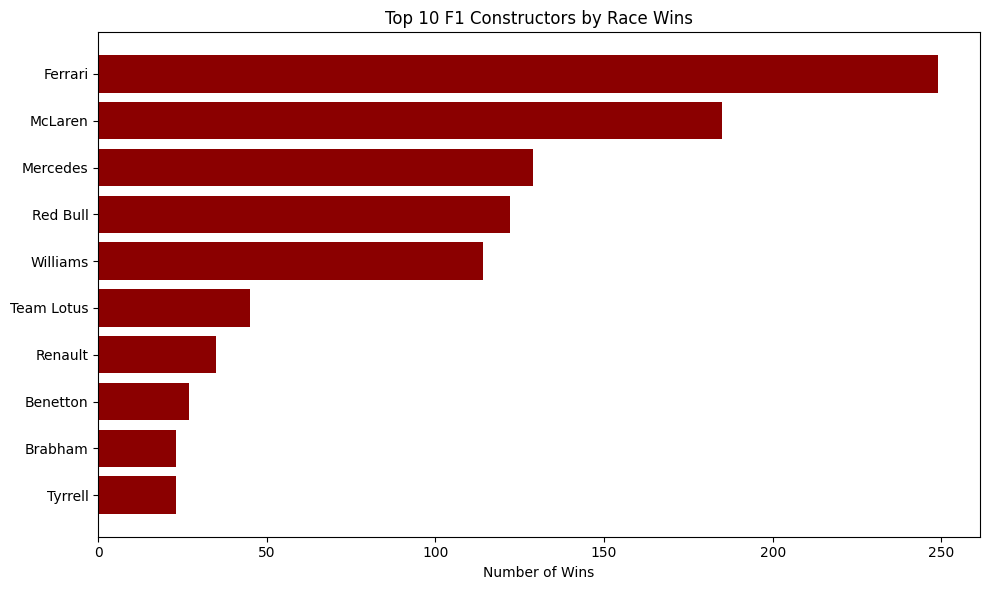

In [6]:
# Top 10 teams by wins
top_teams = winners["constructor_name"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_teams.index, top_teams.values, color="darkred")
plt.xlabel("Number of Wins")
plt.title("Top 10 F1 Constructors by Race Wins")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

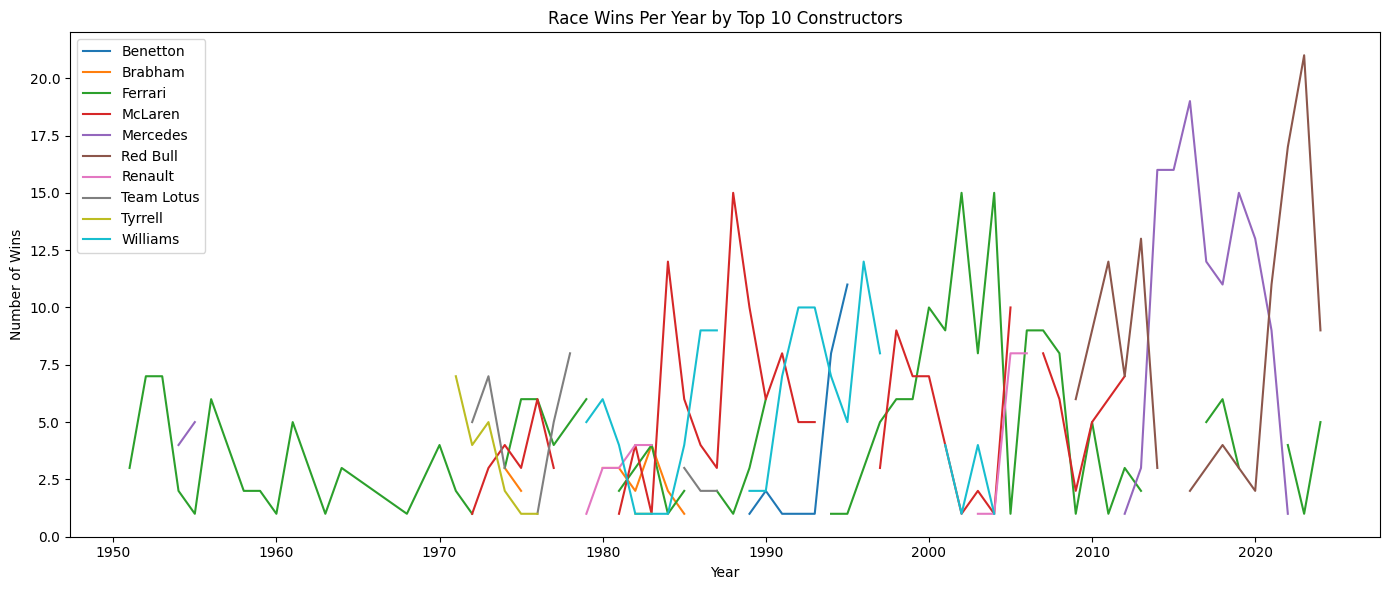

In [12]:
# Wins per year by top 5 constructors
top5_teams = winners["constructor_name"].value_counts().head(10).index

wins_by_year = winners[winners["constructor_name"].isin(top5_teams)] \
    .groupby(["year", "constructor_name"])["is_winner"].sum().unstack()

plt.figure(figsize=(14, 6))
for team in wins_by_year.columns:
    plt.plot(wins_by_year.index, wins_by_year[team], label=team)

plt.xlabel("Year")
plt.ylabel("Number of Wins")
plt.title("Race Wins Per Year by Top 10 Constructors")
plt.legend()
plt.tight_layout()
plt.show()

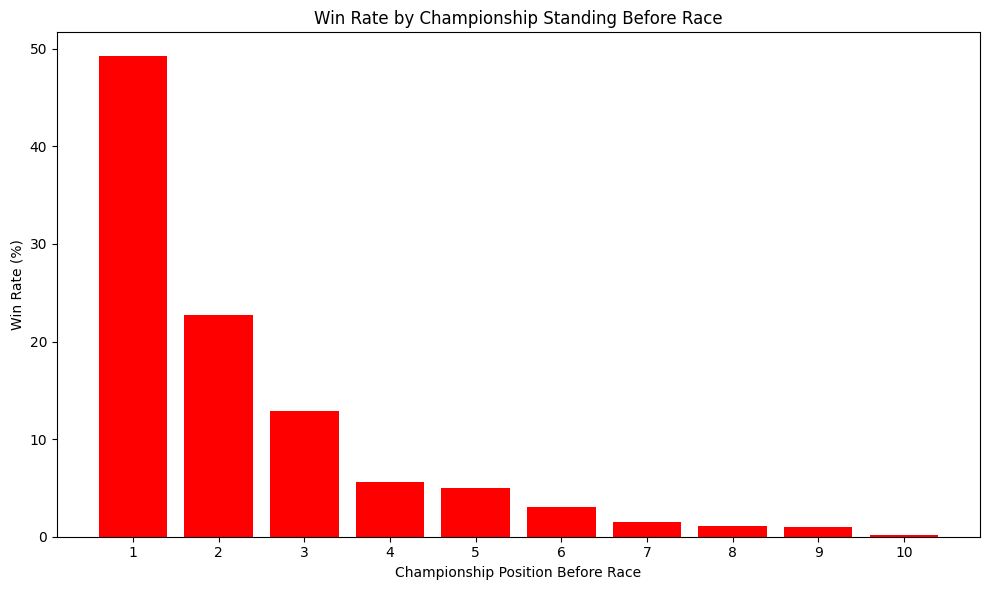

In [8]:
# Win rate by championship position before the race
champ_wins = df[df["champ_pos_pre"] <= 10].groupby("champ_pos_pre")["is_winner"].mean() * 100

plt.figure(figsize=(10, 6))
plt.bar(champ_wins.index, champ_wins.values, color="red")
plt.xlabel("Championship Position Before Race")
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Championship Standing Before Race")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

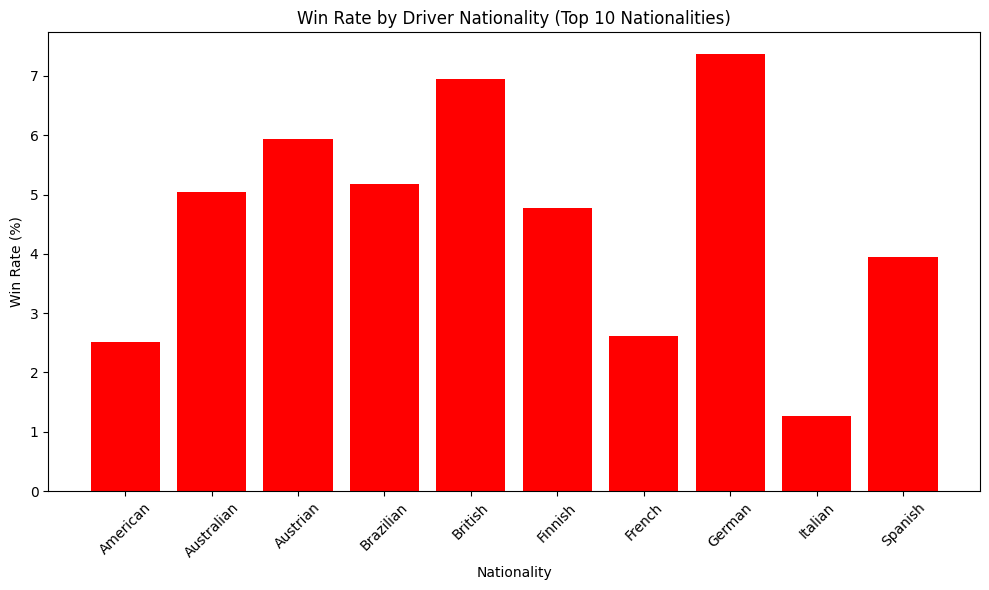

In [9]:
# Win rate by driver nationality (top 10 nationalities by race entries)
top_nationalities = df["nationality"].value_counts().head(10).index
nat_data = df[df["nationality"].isin(top_nationalities)]
nat_wins = nat_data.groupby("nationality")["is_winner"].mean() * 100

plt.figure(figsize=(10, 6))
plt.bar(nat_wins.index, nat_wins.values, color="red")
plt.xlabel("Nationality")
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Driver Nationality (Top 10 Nationalities)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
from scipy import stats

# Split into two groups
pole = df[df["grid"] == 1]["is_winner"]
non_pole = df[df["grid"] != 1]["is_winner"]

# T-test
t_stat, p_value = stats.ttest_ind(pole, non_pole)

print("=== Hypothesis Test 1 ===")
print("H0: Pole position has NO effect on winning")
print("Ha: Pole position DOES increase chance of winning")
print()
print(f"Pole position win rate:     {pole.mean()*100:.1f}%")
print(f"Non-pole position win rate: {non_pole.mean()*100:.1f}%")
print()
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.10f}")
print()
if p_value < 0.05:
    print("Result: REJECT H0 — pole position significantly increases win chance")
else:
    print("Result: FAIL TO REJECT H0 — no significant effect found")

=== Hypothesis Test 1 ===
H0: Pole position has NO effect on winning
Ha: Pole position DOES increase chance of winning

Pole position win rate:     42.3%
Non-pole position win rate: 2.5%

T-statistic: 71.2866
P-value:     0.0000000000

Result: REJECT H0 — pole position significantly increases win chance


In [13]:
# Split into 3 eras
early = df[df["year"] <= 1979]
middle = df[(df["year"] >= 1980) & (df["year"] <= 1999)]
modern = df[df["year"] >= 2000]

# Pole win rate per era
for era, name in [(early, "Early (1950-1979)"), (middle, "Middle (1980-1999)"), (modern, "Modern (2000-2024)")]:
    pole_wr = era[era["grid"] == 1]["is_winner"].mean() * 100
    print(f"{name}: pole win rate = {pole_wr:.1f}%")

# Chi-square test
from scipy.stats import chi2_contingency

def era_table(era):
    pole = era[era["grid"] == 1]["is_winner"]
    return [pole.sum(), len(pole) - pole.sum()]

table = [era_table(early), era_table(middle), era_table(modern)]
chi2, p, dof, expected = chi2_contingency(table)

print()
print("=== Hypothesis Test 2 ===")
print("H0: Pole position win rate is the same across all eras")
print("Ha: Pole position win rate differs across eras")
print()
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print()
if p < 0.05:
    print("Result: REJECT H0 — pole advantage differs significantly across eras")
else:
    print("Result: FAIL TO REJECT H0 — no significant difference across eras")

Early (1950-1979): pole win rate = 36.9%
Middle (1980-1999): pole win rate = 35.5%
Modern (2000-2024): pole win rate = 50.7%

=== Hypothesis Test 2 ===
H0: Pole position win rate is the same across all eras
Ha: Pole position win rate differs across eras

Chi-square statistic: 23.9960
P-value: 0.0000

Result: REJECT H0 — pole advantage differs significantly across eras
